In [1]:
import os
from pathlib import Path
%matplotlib inline
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae


# 1. Evaluate external dataset

In [2]:
import os
from pathlib import Path
%matplotlib inline
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt

In [3]:
from glob import glob
import numpy as np
from gait_ml import plotting
from gait_ml.data.datamodule import ExternalGaitDataModule
%load_ext autoreload
%autoreload 2

### Load external dataset

In [4]:
all_files = np.sort(glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/**/*.npy", recursive=True))

cur_set_to_test = np.arange(len(all_files))

### Visualize the dataset

In [10]:
curr_data = np.load(all_files[0])
plotting.plot_xyz(curr_data[:, 1], curr_data[:, 2], curr_data[:, 3], curr_data[:, -1].astype(int))

### Load best model

In [ ]:
from scipy.spatial.transform import Rotation
from gaitmap.utils.rotations import rotate_dataset
from gaitmap.preprocessing import sensor_alignment
import numpy as np
R = Rotation.from_matrix(np.array([[ 0,   0,  1], 
                                   [ -1,  0, 0], 
                                   [ 0,  -1,  0]]))

In [11]:
with initialize(config_path="../configs", job_name="train", version_base="1.3"):
    config = compose(config_name="train_config")

In [71]:
pl.seed_everything(config.general.random_state)
print(f"Processing: {len(all_files)} samples")

model = LitSeq2Seq(
    input_dim=config.model.input_dim,
    output_dim=config.model.output_dim,
    hidden_dim=config.model.hidden_dim,
    num_layers=config.model.num_layers,
    dropout_prob=config.model.dropout_prob,
    learning_rate=config.model.learning_rate,
    teacher_forcing_ratio=config.model.teacher_forcing_ratio,
)

# model_fpath = "/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold1-GRU-expandlabel8_2025-11-05_16-14-27/checkpoints/model-epoch=46-val_f1score=0.94.ckpt"
model_fpath = "/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp3-Fold1-GRU-expandlabel2_2025-11-10_12-18-37/checkpoints/model-epoch=87-val_f1score=0.87.ckpt"
device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)

Seed set to 42


Processing: 202 samples


 === Currently Evaluating curr_test_idx: 0 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-0.9971, -0.0294, -0.0756,  0.0190, -0.0206,  0.2246])
normalized mean: tensor([-0.5123, -0.2608, -0.0345,  0.0048, -0.1725,  0.4946])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


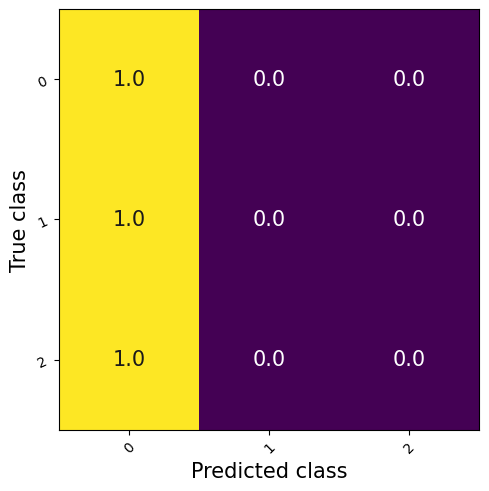

tensor([[1769,    0,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 1 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0615, -0.1636, -0.0214,  0.0190, -0.2091,  0.2481])
normalized mean: tensor([-0.5574, -0.3479, -0.0158,  0.0048, -0.2092,  0.5018])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


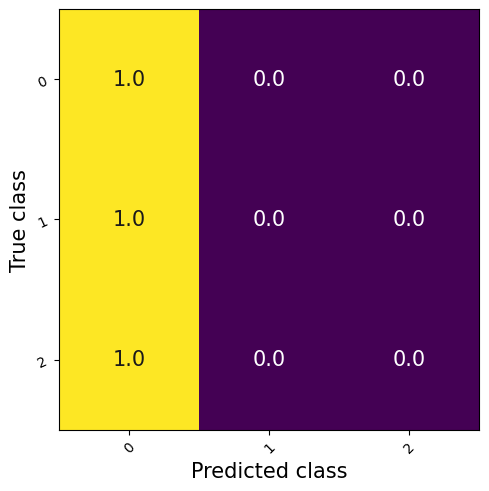

tensor([[1768,    1,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9933, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([0.9994, 0.0000, 0.0000])
MAE overall: 13.0000 ✨
MAE per_class: {1: np.float64(13.0)} ✨
 === Currently Evaluating curr_test_idx: 2 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0635,  0.0139, -0.0083,  0.0181, -0.2184,  0.2543])
normalized mean: tensor([-0.5589, -0.2327, -0.0112,  0.0046, -0.2110,  0.5038])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


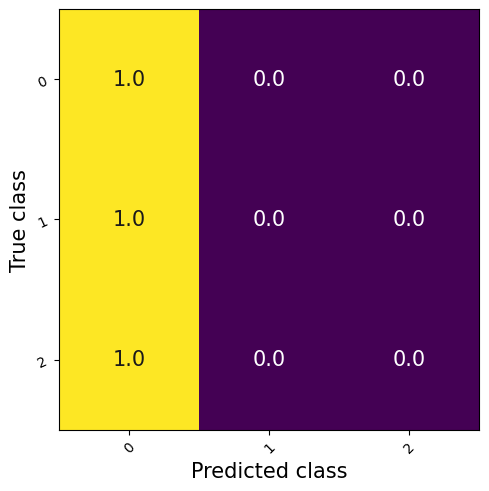

tensor([[1768,    2,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9933, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9989, 0.0000, 0.0000])
MAE overall: 13.5000 ✨
MAE per_class: {1: np.float64(13.5)} ✨
 === Currently Evaluating curr_test_idx: 3 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
old mean: tensor([-1.0681,  0.0247, -0.0071,  0.0207, -0.2279,  0.2672])
normalized mean: tensor([-0.5621, -0.2257, -0.0109,  0.0051, -0.2129,  0.5078])
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


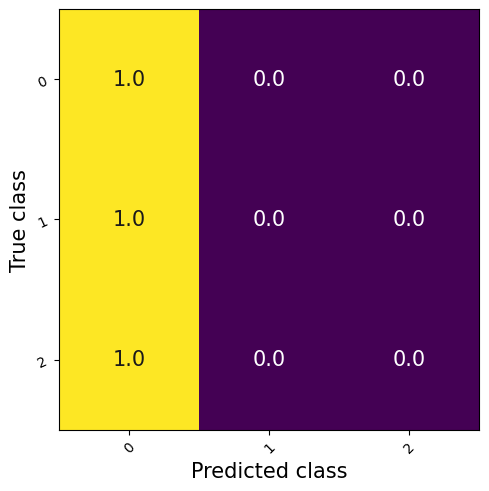

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 4 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
old mean: tensor([-1.0801, -0.0937, -0.0180,  0.0211, -0.2358,  0.2764])
normalized mean: tensor([-0.5705, -0.3025, -0.0146,  0.0052, -0.2144,  0.5106])
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


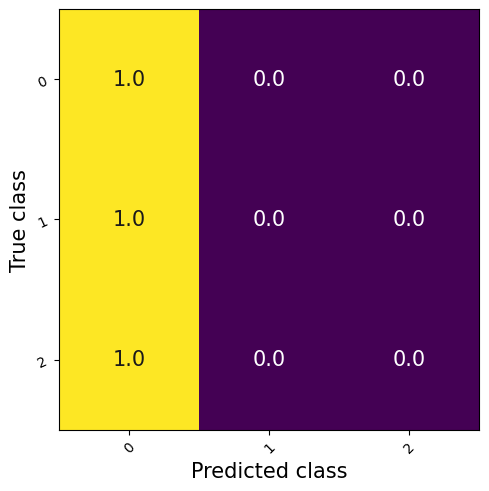

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 5 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0626,  0.0074, -0.1268,  0.0225, -0.1861,  0.2464])
normalized mean: tensor([-0.5582, -0.2369, -0.0521,  0.0055, -0.2047,  0.5013])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


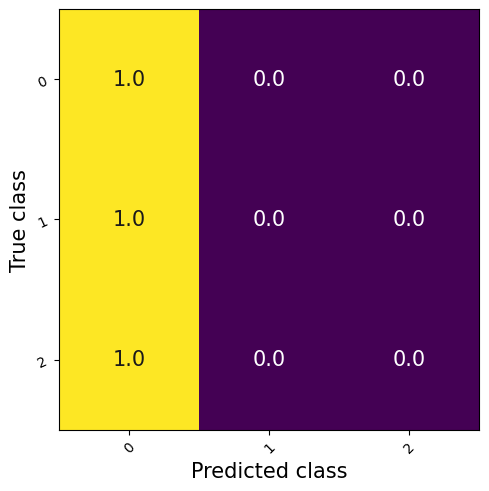

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 6 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0710,  0.1651, -0.1652,  0.0212, -0.1953,  0.2638])
normalized mean: tensor([-0.5641, -0.1345, -0.0654,  0.0052, -0.2065,  0.5067])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


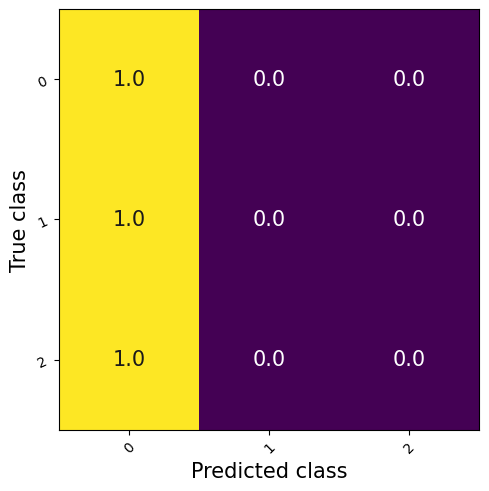

tensor([[1766,    0,    0],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 7 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_03_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0677,  0.0548, -0.1612,  0.0224, -0.2048,  0.2451])
normalized mean: tensor([-0.5618, -0.2061, -0.0640,  0.0055, -0.2083,  0.5009])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


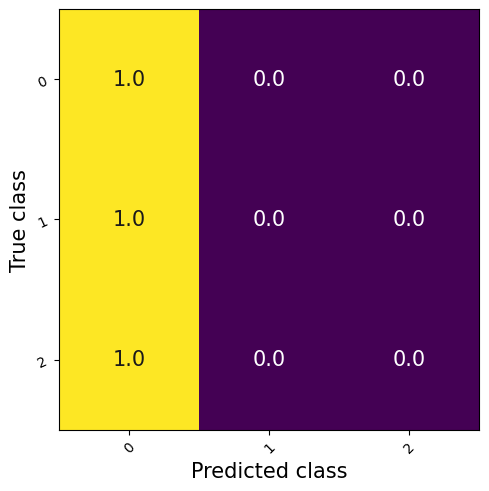

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 8 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_04_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0760,  0.0539, -0.1672,  0.0230, -0.1961,  0.2547])
normalized mean: tensor([-0.5676, -0.2067, -0.0660,  0.0056, -0.2067,  0.5039])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


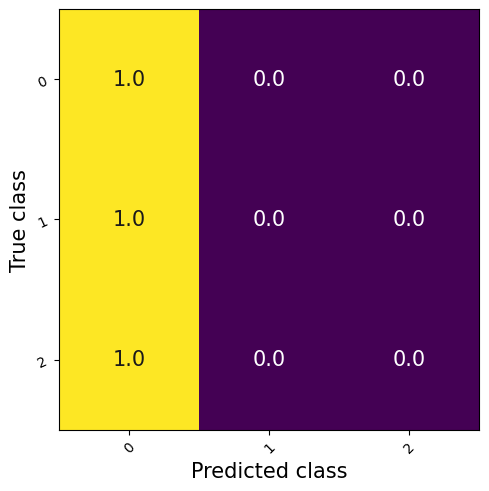

tensor([[1764,    0,    0],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 9 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_05_01.npy
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
old mean: tensor([-1.0764,  0.0995, -0.1795,  0.0223, -0.1889,  0.2493])
normalized mean: tensor([-0.5679, -0.1771, -0.0703,  0.0054, -0.2053,  0.5022])
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


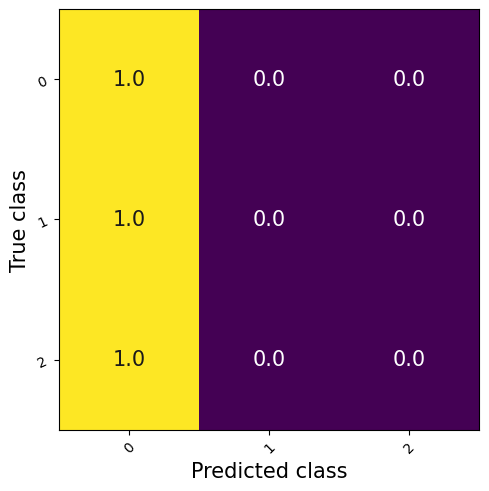

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 10 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_01.npy
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
old mean: tensor([-1.0443,  0.0321, -0.0142,  0.0142, -0.0954,  0.2052])
normalized mean: tensor([-0.5454, -0.2208, -0.0133,  0.0039, -0.1870,  0.4886])
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


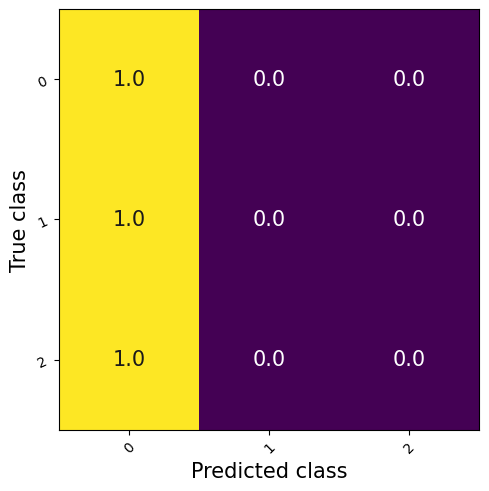

tensor([[2276,    6,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9939, 0.0000, 0.0000])
perclass_precision: tensor([0.9904, 0.0000, 0.0000])
perclass_recall: tensor([0.9974, 0.0000, 0.0000])
MAE overall: nan ✨
MAE per_class: {} ✨
 === Currently Evaluating curr_test_idx: 11 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_02.npy
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
old mean: tensor([-1.0343,  0.0017, -0.0096,  0.0161, -0.0896,  0.2215])
normalized mean: tensor([-0.5383, -0.2406, -0.0117,  0.0043, -0.1859,  0.4936])
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


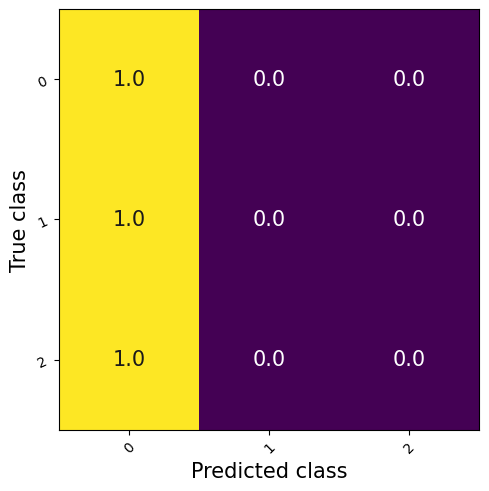

tensor([[2022,    4,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9936, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: 16.0000 ✨
MAE per_class: {1: np.float64(16.0)} ✨
 === Currently Evaluating curr_test_idx: 12 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_03.npy
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
old mean: tensor([-1.0386,  0.0445, -0.0804,  0.0162, -0.1019,  0.2318])
normalized mean: tensor([-0.5414, -0.2128, -0.0361,  0.0043, -0.1883,  0.4968])
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])



KeyboardInterrupt



In [81]:
testset_f1_scores = []
testset_pc_f1_scores = []
testset_pc_precision = []
testset_pc_recall = []
testset_mae = []
testset_pc_mae = []
testset_cm = []

group_assigment = []
for curr_test_idx in cur_set_to_test.tolist():
    print(f" === Currently Evaluating curr_test_idx: {curr_test_idx} === ")
    curr_datamodule = ExternalGaitDataModule(all_files, test_idx=[curr_test_idx], 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=config.data.expand_labels,
                                             zscale=False,
                                            )
    curr_datamodule.setup("test")
    test_dataloader = curr_datamodule.test_dataloader()
    best_model.eval()
    pred=[]
    target=[]
    for sample_input, sample_target in test_dataloader:
        data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
        data_sf = [rotate_dataset(i, R) for i in data_sf]
        # data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
        sample_input = torch.tensor(np.stack(([i.values for i in data_sf]))).to(torch.float32)
        
        global_mean = torch.tensor([-0.26744056,  0.37221455,  0.02437649, -0.00636486,  0.86478071, -1.37257239])
        global_var = torch.tensor([1.42450657, 1.53985195, 2.90120095, 5.26959429, 5.13357321, 3.22938361])
        print("old mean:", sample_input.mean([0, 1]))
        sample_input = (sample_input-global_mean)/global_var
        print("normalized mean:", sample_input.mean([0, 1]))
        sample_input = sample_input.to(device_)
        sample_target = sample_target.to(device_)
        print(sample_input.shape)
        with torch.no_grad():
            predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
        pred.append(predicted_output)
        target.append(sample_target)
    
    cur_pred = torch.concat(pred).reshape(-1, 3)
    cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
    cur_target = torch.concat(target).reshape(-1)
    reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
    print("Pred", cur_pred.shape, "Target", cur_target.shape)
    
    ALIGN_TOLERANCE = 3
    merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
    merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
    aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
    
    
    cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
    cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    fig_, ax_ = cm.plot()
    plt.show()
    unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
    unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    ucm_tensor = unnormalized_cm.compute()
    testset_cm.append(ucm_tensor)
    print(ucm_tensor)
    
    num_classes = 3
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

    pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
    perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_f1_scores.append(perclass_f1scores)
    print(f"perclass_f1scores:", perclass_f1scores)

    pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
    perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_precision.append(perclass_precision)
    print(f"perclass_precision:", perclass_precision)

    pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
    perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_recall.append(perclass_recall)
    print(f"perclass_recall:", perclass_recall)

    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    
    overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
    overall = overall.item() if not np.isnan(overall) else np.nan
    print(f"MAE overall: {overall:.4f} ✨")
    print(f"MAE per_class: {per_class} ✨")
    testset_f1_scores.append(f1_macro_score)
    testset_mae.append(overall)
    testset_pc_mae.append(per_class)
    # group_assigment.append(grouping[curr_test_idx])
    # break

### Understand how to rotate the data

In [ ]:
# data_x = pd.DataFrame(reshaped_input)
# data_x.columns = ['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']

# from scipy.spatial.transform import Rotation
# from gaitmap.utils.rotations import rotate_dataset
# from gaitmap.preprocessing import sensor_alignment
# import numpy as np
# R = Rotation.from_matrix(np.array([[ 0,   0,  1], 
#                                    [ -1,  0, 0], 
#                                    [ 0,  -1,  0]]))
# data_sf = rotate_dataset(data_x, R)
# data_sf = sensor_alignment.align_dataset_to_gravity(data_sf, 100)

In [76]:
reshaped_input.shape


(1536, 6)

In [78]:
merged_preds

array([0, 0, 0, ..., 0, 0, 0], shape=(1536,))

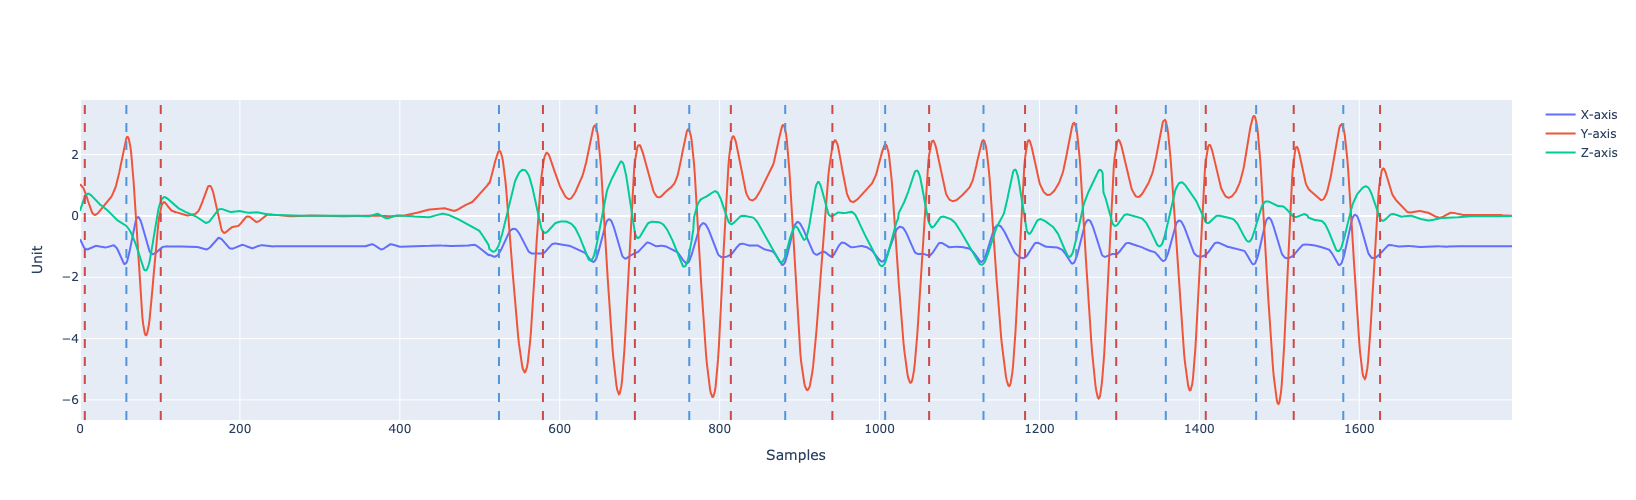

In [42]:
plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_targets.astype(int))

In [ ]:
plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_preds.astype(int))

### Check how to rotate the data

In [ ]:
from scipy.spatial.transform import Rotation
from gaitmap.utils.rotations import rotate_dataset
from gaitmap.preprocessing import sensor_alignment
import numpy as np
R = Rotation.from_matrix(np.array([[ 0,   0,  1], 
                                   [ -1,  0, 0], 
                                   [ 0,  -1,  0]]))
data_sf = rotate_dataset(data_x, R)
data_sf = sensor_alignment.align_dataset_to_gravity(data_sf, 100)

data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
data_sf = [rotate_dataset(i, R) for i in data_sf]
data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
torch.tensor(np.stack(([i.values for i in data_sf])))